## Generative AI Project: Diffusion. Image-background Generation.

## Goal:

The goal of this task is to fine-tune the difussion model using a dataset of dtd(images of different textures for postcard background generation, enabling it to generate new backgrounds based on text prompts.

## Download emoji dataset
from https://www.robots.ox.ac.uk/~vgg/data/dtd/

In [3]:
import scipy.io

# Load the imdb.mat file
data = scipy.io.loadmat('/kaggle/input/did-dataset/dtd/imdb/imdb.mat')

/dtd/images
Prompt: a background with a matted texture
/kaggle/input/did-dataset/dtd/images/matted/matted_0089.jpg


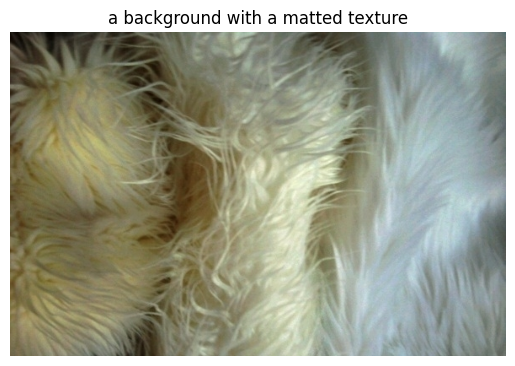

In [4]:
import os
import scipy.io
from PIL import Image
import matplotlib.pyplot as plt
import random
import tarfile
import requests
# Step 1: Extract the tar.gz file
def extract_dtd(tar_path, extract_dir):
    extracted_path = os.path.join(extract_dir, "dtd")
    if not os.path.exists(extracted_path):
        with tarfile.open(tar_path, "r:gz") as tar:
            tar.extractall(path=extract_dir)
            print(f"Extracted to: {extracted_path}")
    else:
        print("Already extracted.")
    return extracted_path

# Step 2: Load 'imdb.mat' to get the image data and metadata
def load_imdb_data(imdb_file):
    imdb_data = scipy.io.loadmat(imdb_file)
    return imdb_data

# Step 3: Show image + prompt
def show_random_image_with_prompt(imdb_data, images_dir):
    # Извлекаем нужные данные
    image_names = imdb_data['images'][0][0][1][0]  # 'name' field (array of shape (N,))
    image_classes = imdb_data['images'][0][0][3][0]  # 'class' field (array of shape (N,))
    class_names = imdb_data['meta'][0][0][1][0]  # List of class names

    # Выбираем случайный индекс
    idx = random.randint(0, len(image_names) - 1)
    image_name = image_names[idx][0]  # Строка с путем
    class_index = image_classes[idx] - 1  # Индексация с 0
    class_name = class_names[class_index][0]  # Получаем строку из массива

    # Генерируем путь к изображению
    image_path = '/kaggle/input/did-dataset' + os.path.join(images_dir, image_name)

    # Генерируем prompt
    prompt = f"a background with a {class_name} texture"
    print(f"Prompt: {prompt}")

    print(image_path)

    # Открываем и показываем изображение
    image = Image.open(image_path)
    plt.imshow(image)
    plt.axis('off')
    plt.title(prompt)
    plt.show()

# --- MAIN ---
imdb_file = "/kaggle/input/did-dataset/dtd/imdb/imdb.mat"

# Load the imdb.mat file
imdb_data = load_imdb_data(imdb_file)
print(imdb_data['imageDir'][0][4:])

# Set the images directory path (based on the provided structure)
images_dir = os.path.join('/kaggle/input/did-dataset', imdb_data['imageDir'][0][4:])

# Show a random image with the prompt
show_random_image_with_prompt(imdb_data, images_dir)

In [5]:
import csv

def save_image_prompts_to_csv(imdb_data, images_dir, output_csv_path):
    image_names = imdb_data['images'][0][0][1][0]
    image_classes = imdb_data['images'][0][0][3][0]
    class_names = imdb_data['meta'][0][0][1][0]

    with open(output_csv_path, mode='w', newline='', encoding='utf-8') as file:
        writer = csv.writer(file)
        writer.writerow(['image_path', 'prompt'])  # Заголовки

        for idx in range(len(image_names)):
            image_name = image_names[idx][0]
            class_index = image_classes[idx] - 1
            class_name = class_names[class_index][0]
            image_path = "/kaggle/input/did-dataset" + os.path.join(images_dir, image_name)
            prompt = f"a background with a {class_name} texture"
            writer.writerow([image_path, prompt])

    print(f"CSV saved to {output_csv_path}")
output_csv_path = "dtd_prompts.csv"
save_image_prompts_to_csv(data, images_dir, output_csv_path)

CSV saved to dtd_prompts.csv


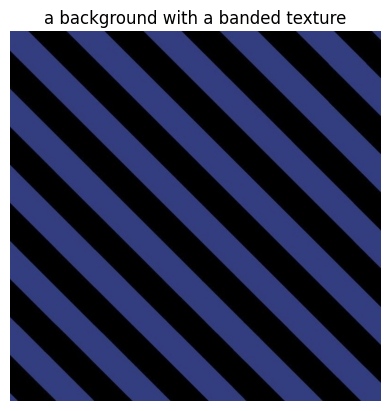

In [7]:
    import pandas as pd

    df = pd.read_csv("dtd_prompts.csv")
    idx = 21
    image = Image.open(df.loc[idx].image_path)
    plt.imshow(image)
    plt.axis('off')
    plt.title(df.loc[idx].prompt)
    plt.show()

In [8]:
dff = pd.read_csv("/kaggle/working/dtd_prompts.csv")
dff.head()

,image_path,prompt
0,/kaggle/input/did-dataset/dtd/images/banded/ba...,a background with a banded texture
1,/kaggle/input/did-dataset/dtd/images/banded/ba...,a background with a banded texture
2,/kaggle/input/did-dataset/dtd/images/banded/ba...,a background with a banded texture
3,/kaggle/input/did-dataset/dtd/images/banded/ba...,a background with a banded texture
4,/kaggle/input/did-dataset/dtd/images/banded/ba...,a background with a banded texture


## Download and import libraries

In [9]:
!pip install -q diffusers transformers torch torchvision datasets bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 10.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.3 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 81.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 22.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 9.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0

In [10]:
import torch
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from PIL import Image, ImageDraw, ImageFont
from diffusers import StableDiffusionPipeline, UNet2DConditionModel, DDPMScheduler, AutoencoderKL, DDPMPipeline
from transformers import CLIPTokenizer, CLIPTextModel
import os
import pandas as pd
from dataclasses import dataclass
import matplotlib.pyplot as plt
from diffusers.optimization import get_cosine_schedule_with_warmup
import bitsandbytes as bnb
from accelerate import Accelerator, notebook_launcher
from huggingface_hub import create_repo, upload_folder
from tqdm.auto import tqdm
from pathlib import Path
import torch.nn.functional as F

2025-04-13 09:28:38.075566: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744536518.378397      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744536518.455428      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Initialize configuration class for training

In [11]:
@dataclass
class TrainingConfig:
    image_size: int = 256
    train_batch_size: int = 4
    eval_batch_size: int = 4
    num_epochs: int = 15
    gradient_accumulation_steps = 1
    learning_rate: float = 5e-6
    lr_warmup_steps: int = 500
    save_image_epochs: int = 10
    save_model_epochs: int = 30
    mixed_precision: str = "fp16"
    output_dir: str = "fine_tuned_diffuser_dtd"

    push_to_hub = False
    hub_private_repo = False
    overwrite_output_dir = True
    seed = 0

config = TrainingConfig()

## Initialize Custom dataset for images

In [12]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

csv_path = "/kaggle/working/dtd_prompts.csv"
dtd_data = pd.read_csv(csv_path)

class DTDTextureDataset(Dataset):
    def __init__(self, root_dir, csv_data, transform=None):
        self.image_paths = [os.path.join(root_dir, path) for path in csv_data['image_path']]
        self.prompts = csv_data['prompt'].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)
        
        prompt = self.prompts[idx]
        return image, prompt

# Example transform setup
transform = transforms.Compose([
    transforms.Resize((config.image_size, config.image_size)),
    transforms.CenterCrop(config.image_size),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

## Loading and Preparing Subset of Emoji Dataset for Training

In [13]:
image_dir = "/kaggle/input/did-dataset/images"
dataset = DTDTextureDataset(root_dir=image_dir, csv_data=dtd_data, transform=transform)
subset_size = 2000
subset_indices = list(range(subset_size))
train_subset = Subset(dataset, subset_indices)
train_dataloader = DataLoader(train_subset, batch_size=config.train_batch_size, shuffle=True)

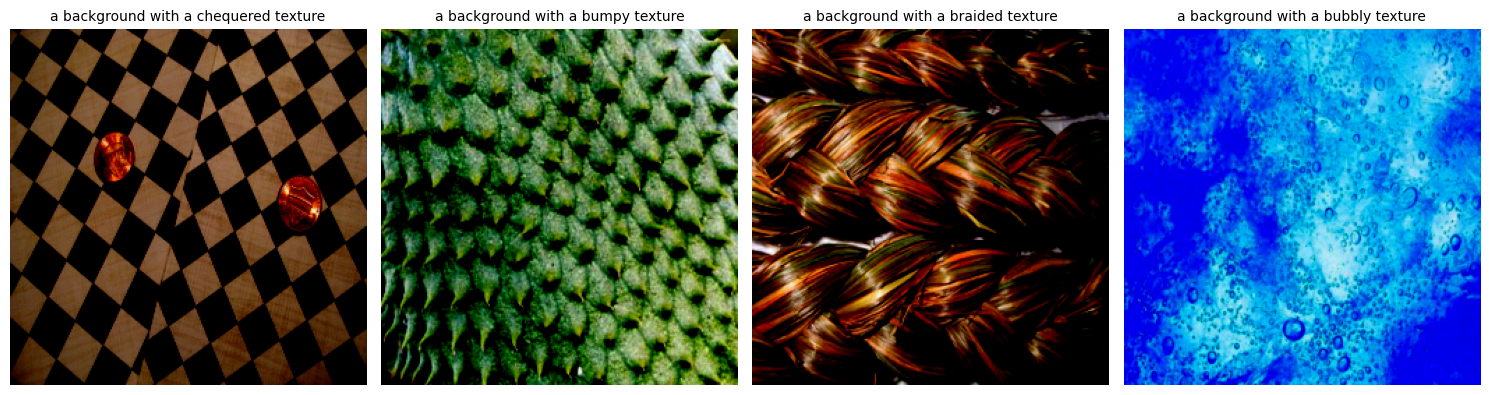

In [14]:
# Function to display images with prompts
def show_images(images, prompts, num_images=4):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(num_images):
        if i >= len(images):
            break
        image = images[i].permute(1, 2, 0).numpy()
        image = image / image.max()
        axes[i].imshow(image)
        truncated_prompt = (prompts[i][:50] + '...') if len(prompts[i]) > 50 else prompts[i]
        axes[i].set_title(truncated_prompt, fontsize=10)
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

for images, prompts in train_dataloader:
    show_images(images, prompts, num_images=4)
    break

In [15]:
len(dataset)

5640

In [17]:
len(train_dataloader)

500

## Checking noise sheduler on image

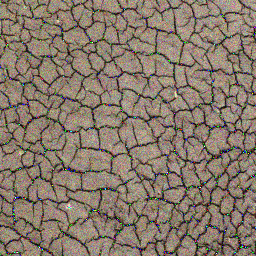

In [19]:
for images, prompts in train_dataloader:
    image = images[0].unsqueeze(0)
    sample_image = images[0].unsqueeze(0)
    prompt = prompts[0]
    break   
noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
noise = torch.randn(sample_image.shape)
timesteps = torch.LongTensor([50])
noisy_image = noise_scheduler.add_noise(sample_image, noise, timesteps)
Image.fromarray(((noisy_image.permute(0, 2, 3, 1) + 1.0) * 127.5).type(torch.uint8).numpy()[0])

## Loading Pretrained Models for Stable Diffusion

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "CompVis/stable-diffusion-v1-4"

tokenizer = CLIPTokenizer.from_pretrained(model_path, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(model_path, subfolder="text_encoder")
unet = UNet2DConditionModel.from_pretrained(model_path, subfolder="unet")
noise_scheduler = DDPMScheduler.from_pretrained(model_path, subfolder="scheduler")
vae = AutoencoderKL.from_pretrained(model_path, subfolder="vae")

vae.requires_grad_(False)
text_encoder.requires_grad_(False)

weight_dtype = torch.float32
text_encoder.to(device, dtype=weight_dtype)
vae.to(device, dtype=weight_dtype)
unet.to(device, dtype=weight_dtype)
unet.train()

tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

scheduler_config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

UNet2DConditionModel(
  (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=320, out_features=1280, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=1280, out_features=1280, bias=True)
  )
  (down_blocks): ModuleList(
    (0): CrossAttnDownBlock2D(
      (attentions): ModuleList(
        (0-1): 2 x Transformer2DModel(
          (norm): GroupNorm(32, 320, eps=1e-06, affine=True)
          (proj_in): Conv2d(320, 320, kernel_size=(1, 1), stride=(1, 1))
          (transformer_blocks): ModuleList(
            (0): BasicTransformerBlock(
              (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
              (attn1): Attention(
                (to_q): Linear(in_features=320, out_features=320, bias=False)
                (to_k): Linear(in_features=320, out_features=320, bias=False)
                (to_v): Linear(in_features=320, out_fe

## Optimizer setup

In [ ]:
optimizer = bnb.optim.Adam8bit(unet.parameters(), lr=config.learning_rate) #reduces memory usage

lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=config.lr_warmup_steps,
    num_training_steps=(len(train_dataloader) * config.num_epochs),
)

## Training loop

In [22]:
from accelerate import Accelerator
from huggingface_hub import create_repo, upload_folder
from tqdm.auto import tqdm
from pathlib import Path
import os
import torch
import torch.nn.functional as F
from diffusers import DDPMPipeline

def train_loop(config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler, tokenizer, text_encoder, vae):
    print("Starting training loop...")
    accelerator = Accelerator(
        mixed_precision=config.mixed_precision,
        gradient_accumulation_steps=config.gradient_accumulation_steps,
        log_with="tensorboard",
        project_dir=os.path.join(config.output_dir, "logs"),
    )

    if accelerator.is_main_process:
        if config.output_dir is not None:
            os.makedirs(config.output_dir, exist_ok=True)
        if config.push_to_hub:
            repo_id = create_repo(
                repo_id=config.hub_model_id or Path(config.output_dir).name, exist_ok=True
            ).repo_id
        accelerator.init_trackers("train_example")

    model, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(
        model, optimizer, train_dataloader, lr_scheduler
    )

    global_step = 0

    for epoch in range(config.num_epochs):
        print("epoch", epoch)
        epoch_loss = 0

        for step, batch in enumerate(train_dataloader):
            images, prompt = batch
            clean_images = images
            prompts = prompt

            with torch.no_grad():
                latents = vae.encode(clean_images).latent_dist.sample()
                latents = latents * vae.config.scaling_factor

            tokenized_prompt = tokenizer(prompts, padding=True, truncation=True, return_tensors="pt").to(latents.device)
            with torch.no_grad():
                encoder_hidden_states = text_encoder(**tokenized_prompt).last_hidden_state

            noise = torch.randn(latents.shape, device=latents.device)
            bs = latents.shape[0]

            timesteps = torch.randint(
                0, noise_scheduler.config.num_train_timesteps, (bs,), device=latents.device,
                dtype=torch.long
            )
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

            with accelerator.accumulate(model):
                noise_pred = model(noisy_latents, timesteps, encoder_hidden_states=encoder_hidden_states)[0]
                loss = F.mse_loss(noise_pred, noise)
                accelerator.backward(loss)

                if accelerator.sync_gradients:
                    accelerator.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()

            epoch_loss += loss.item()

            global_step += 1

        if accelerator.is_main_process:
            avg_loss = epoch_loss / len(train_dataloader)
            print(f"Epoch {epoch} completed. Average loss: {avg_loss:.4f}")
            
            if (epoch + 1) % config.save_model_epochs == 0 or epoch == config.num_epochs - 1:
                pipeline = DDPMPipeline(unet=accelerator.unwrap_model(model), scheduler=noise_scheduler)

                if config.push_to_hub:
                    upload_folder(
                        repo_id=repo_id,
                        folder_path=config.output_dir,
                        commit_message=f"Epoch {epoch}",
                        ignore_patterns=["step_*", "epoch_*"]
                    )
                else:
                    pipeline.save_pretrained(config.output_dir)

In [24]:
from accelerate import notebook_launcher
args = (config, unet, noise_scheduler, optimizer, train_dataloader, lr_scheduler, tokenizer, text_encoder, vae)

notebook_launcher(train_loop, args, num_processes=1)

Launching training on one GPU.
Starting training loop...
Epoch 0 completed. Average loss: 0.1475
Epoch 1 completed. Average loss: 0.1524
Epoch 2 completed. Average loss: 0.1558
Epoch 3 completed. Average loss: 0.1483
Epoch 4 completed. Average loss: 0.1518
Epoch 5 completed. Average loss: 0.1589
Epoch 6 completed. Average loss: 0.1576
Epoch 7 completed. Average loss: 0.1555
Epoch 8 completed. Average loss: 0.1475
Epoch 9 completed. Average loss: 0.1470
Epoch 10 completed. Average loss: 0.1489
Epoch 11 completed. Average loss: 0.1568
Epoch 12 completed. Average loss: 0.1494
Epoch 13 completed. Average loss: 0.1548
Epoch 14 completed. Average loss: 0.1568


## Save the model to Hugging Face Hub

In [79]:
from diffusers import DDPMPipeline
from pathlib import Path
import os

# === Step 1: Define paths and repo ID ===
output_dir = "/kaggle/working/fine-tuned"  # e.g., "./models/ddpm-poem-background"
repo_id = "Nazgulitos/background-generator-with-stable-diffusion-v1-4"  # Your HF repo name

# === Step 2: Create the pipeline from the trained components ===
unet_path = "/kaggle/working/fine_tuned_diffuser_dtd/unet"
unet = UNet2DConditionModel.from_pretrained(unet_path)
pipeline = StableDiffusionPipeline(
    unet=unet,
    scheduler=noise_scheduler,
    vae=vae,
    text_encoder=text_encoder,
    tokenizer=tokenizer,
    feature_extractor=None,
    safety_checker=None 
)
pipeline.save_pretrained(output_dir)


# === Step 3: Push pipeline to the Hub ===
pipeline.push_to_hub(repo_id)
print(f"Pipeline pushed to: https://huggingface.co/{repo_id}")

# === Step 4: Push tokenizer (and model, if it's a transformer-based one) ===
tokenizer.push_to_hub(repo_id)

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Upload 3 LFS files:   0%|          | 0/3 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Pipeline pushed to: https://huggingface.co/Nazgulitos/background-generator-with-stable-diffusion-v1-4
Skipping model.push_to_hub because: name 'model' is not defined


In [80]:
# model pushing
try:
    unet.push_to_hub(repo_id)
except Exception as e:
    print("Skipping model.push_to_hub because:", str(e))

#### inference

In [99]:
from diffusers import DiffusionPipeline

pipe = DiffusionPipeline.from_pretrained("Nazgulitos/background-generator-with-stable-diffusion-v1-4", torch_dtype=torch.float16)
pipe.to("cuda")
prompt = "A background for birthday"
image = pipe(prompt, num_inference_steps=50).images[0]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/50 [00:00<?, ?it/s]

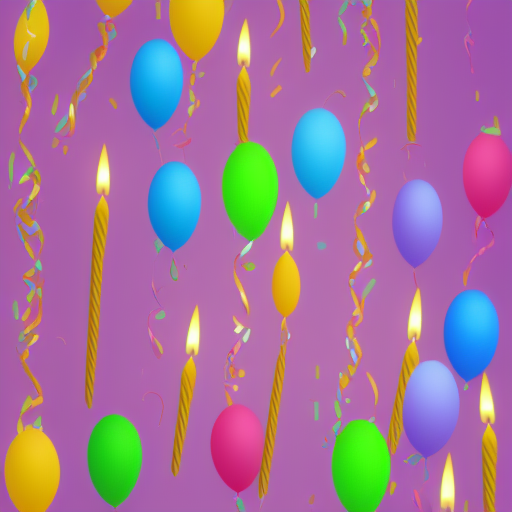

In [100]:
image

## Model inference

In [26]:
import os
from PIL import Image
import matplotlib.pyplot as plt

def generate_and_display_images(prompts, output_folder="generations", pipeline=None, num_inference_steps=50):
    # Ensure the generations folder exists
    os.makedirs(output_folder, exist_ok=True)

    # List to store generated image paths and prompts
    generated_images = []

    # Generate and save images for each prompt
    for i, prompt in enumerate(prompts):
        # Generate image
        image = pipeline(prompt, num_inference_steps=num_inference_steps).images[0]
        
        # Save image with prompt as filename
        filename = f"{output_folder}/image_{i+1}_{prompt.replace(' ', '_')}.png"
        image.save(filename)

        # Add image path and prompt to the list for displaying
        generated_images.append((filename, prompt))

    # Create a figure with a number of subplots based on the number of generated images
    fig, axes = plt.subplots(1, len(generated_images), figsize=(15, 5))  # 1 row, multiple columns

    # Iterate over the generated images and their prompts
    for ax, (image_path, prompt) in zip(axes, generated_images):
        # Open the image
        display_image = Image.open(image_path)
        
        # Display the image
        ax.imshow(display_image)
        ax.axis('off')  # Turn off axis for a cleaner view
        ax.set_title(prompt, fontsize=10)  # Set the prompt as the title

    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/50 [00:00<?, ?it/s]

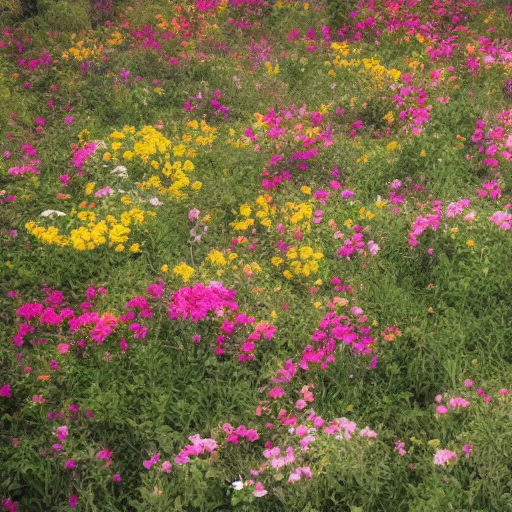

In [27]:
unet_path = "/kaggle/working/fine_tuned_diffuser_dtd/unet"
unet = UNet2DConditionModel.from_pretrained(unet_path)
pipeline = StableDiffusionPipeline(
    unet=unet,
    scheduler=noise_scheduler,
    vae=vae,
    text_encoder=text_encoder,
    tokenizer=tokenizer,
    feature_extractor=None,
    safety_checker=None 
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pipeline.to(device)

# Generate an image from a prompt
prompt = "A background with flowers"
generated_image = pipeline(prompt).images[0]
generated_image

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

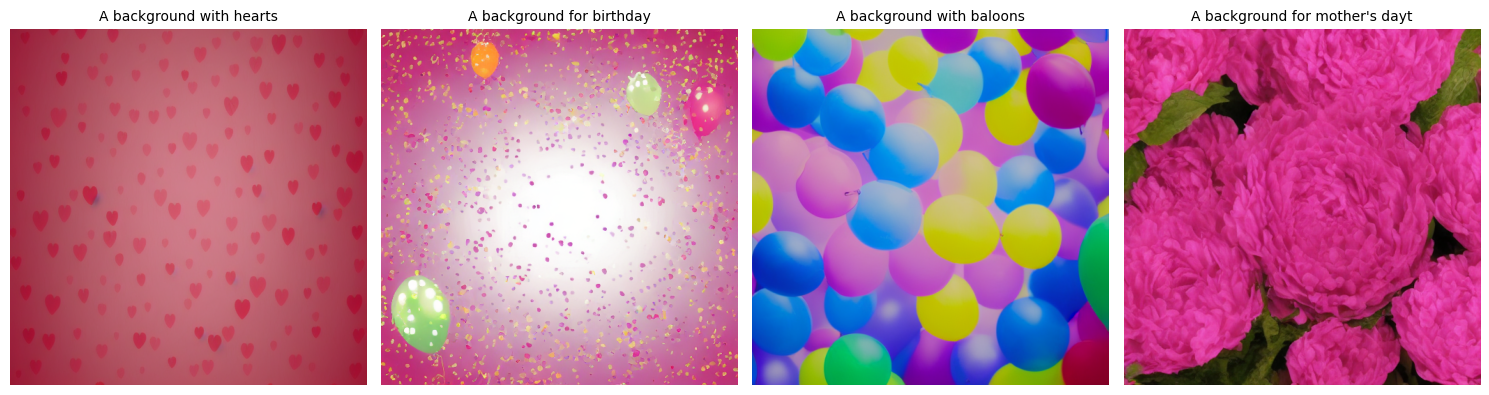

In [32]:
# List of emoji prompts
prompts = [
    "A background with hearts",
    "A background for birthday",
    "A background with baloons",
    "A background for mother's day"
]

# Call the method with the list of prompts
generate_and_display_images(prompts, output_folder="generations", pipeline=pipeline, num_inference_steps=50)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

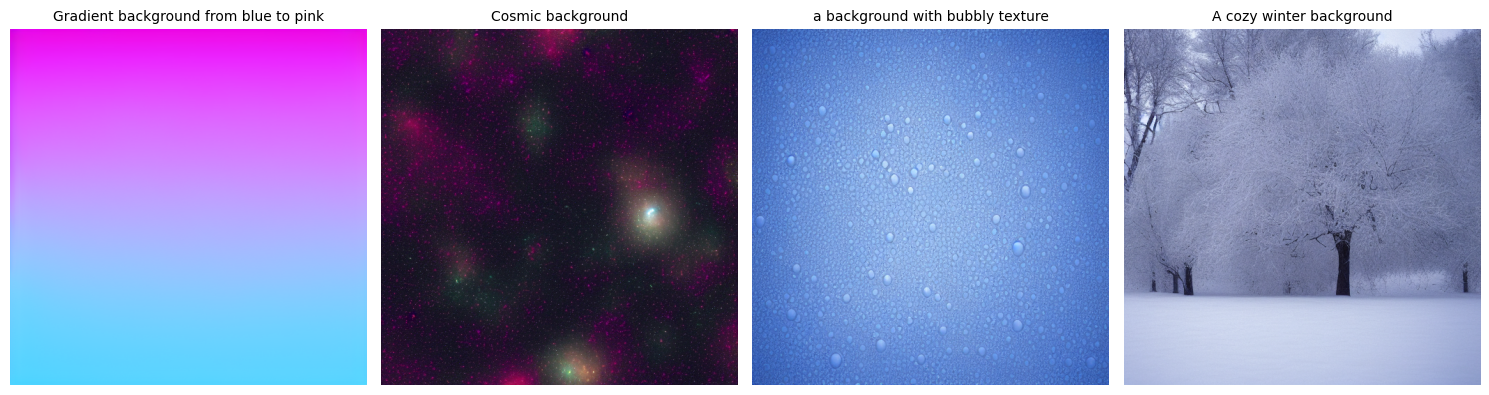

In [33]:
# List of emoji prompts
prompts = [
    "Gradient background from blue to pink",
    "Cosmic background",
    "a background with bubbly texture",
    "A cozy winter background",
]
# Call the method with the list of prompts
generate_and_display_images(prompts, output_folder="generations", pipeline=pipeline, num_inference_steps=50)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

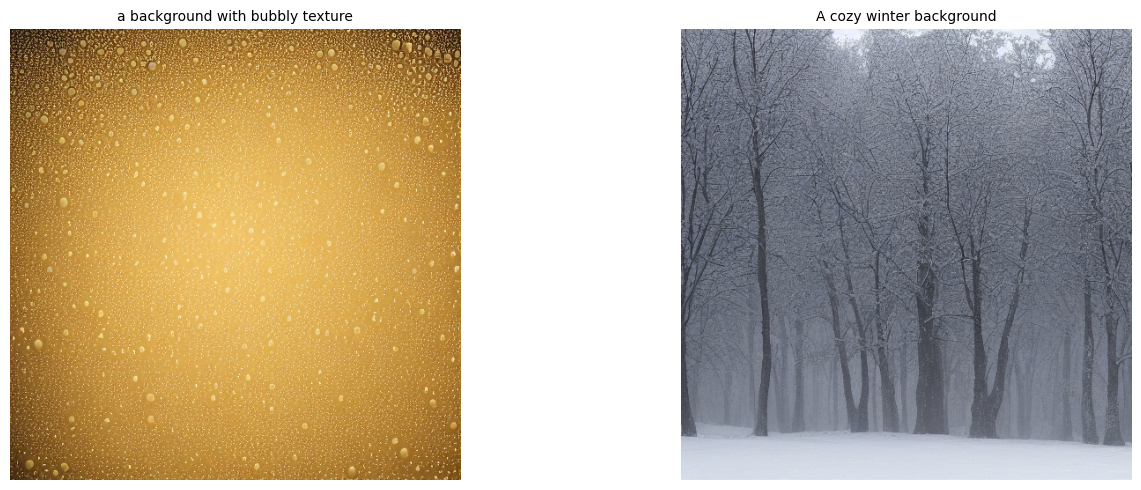

In [31]:
# List of emoji prompts
prompts = [
    "a background with bubbly texture",
    "A cozy winter background",
]

# Call the method with the list of prompts
generate_and_display_images(prompts, output_folder="generations", pipeline=pipeline, num_inference_steps=50)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

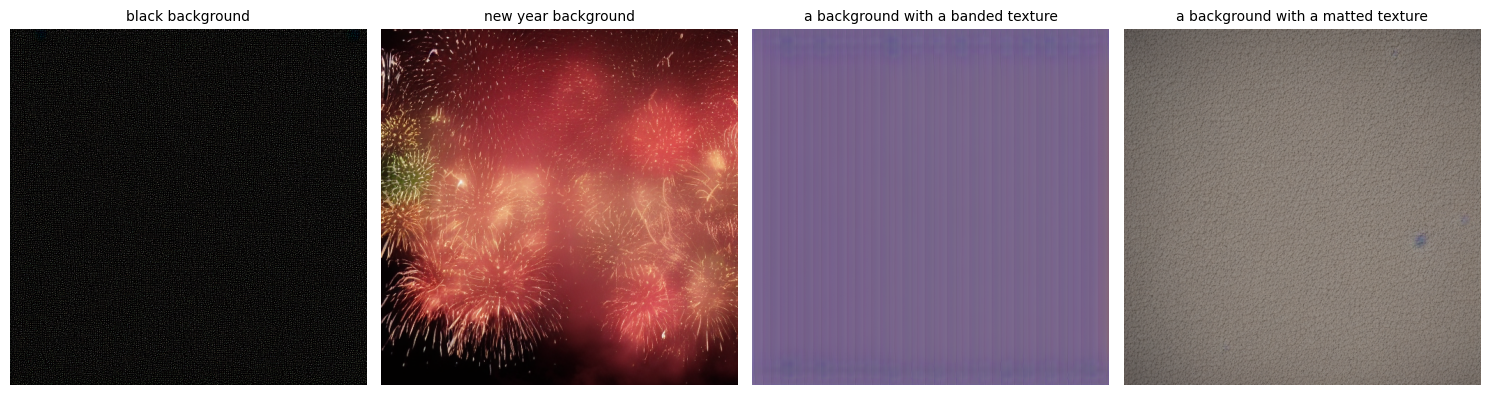

In [34]:
# List of emoji prompts
prompts = [
    "black background",
    "new year background",
    "a background with a banded texture",
    "a background with a matted texture",
]
# Call the method with the list of prompts
generate_and_display_images(prompts, output_folder="generations", pipeline=pipeline, num_inference_steps=50)